# 1. Load Data

In [2]:
import pandas as pd

df = pd.read_csv('/content/Polypropylene Futures Historical Data (1).csv')
display(df.head())

,Date,Price,Open,High,Low,Vol.,Change %
0,10-01-2019,"9,299.00","9,300.00","9,300.00","9,290.00",0.72K,-0.16%
1,11-01-2019,"9,339.00","9,299.00","9,380.00","9,299.00",3.43K,0.43%
2,14-01-2019,"9,333.00","9,346.00","9,350.00","9,300.00",0.29K,-0.06%
3,15-01-2019,"9,232.00","8,800.00","9,839.00","8,800.00",1.71K,-1.08%
4,16-01-2019,"9,222.00","9,222.00","9,222.00","9,222.00",NaN,-0.11%


# 2. Remove Unnecessary Columns

In [3]:
columns_to_drop = ['Open', 'High', 'Low', 'Vol.', 'Change %']
df = df.drop(columns=columns_to_drop)
display(df.head())

,Date,Price
0,10-01-2019,"9,299.00"
1,11-01-2019,"9,339.00"
2,14-01-2019,"9,333.00"
3,15-01-2019,"9,232.00"
4,16-01-2019,"9,222.00"


# 3. Prepare Data for Time Series Analysis

In [5]:

df.describe()

,Price
count,1491.000000
mean,8010.655936
std,653.895083
min,6021.000000
25%,7520.000000
50%,7915.000000
75%,8513.000000
max,10296.000000


### Interpretation of Data Overview

*   **`df.describe()`**: Provides key statistics for the 'Price' column, such as count, mean, standard deviation, minimum, maximum, and quartiles. This gives us a quick summary of the central tendency, dispersion, and range of the price data.
    *   The `mean` price is approximately 8010.66, with a `standard deviation` of about 653.90, indicating a moderate spread in prices.
    *   Prices range from a `minimum` of 6021.00 to a `maximum` of 10296.00.
*   **`df.info()`**: Confirms that there are 1491 entries without any null values for the 'Price' column, and the 'Date' column has been successfully converted to a `DatetimeIndex` which is crucial for time series analysis. The 'Price' column is correctly identified as `float64`.

In [4]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Remove commas from 'Price' column and convert to numeric
df['Price'] = df['Price'].str.replace(',', '', regex=False).astype(float)

# Set 'Date' as the index
df = df.set_index('Date')

# Sort the DataFrame by date index
df = df.sort_index()

display(df.head())
display(df.info())

,Price
Date,
2019-01-10,9299.0
2019-01-11,9339.0
2019-01-14,9333.0
2019-01-15,9232.0
2019-01-16,9222.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1491 entries, 2019-01-10 to 2025-03-07
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   1491 non-null   float64
dtypes: float64(1)
memory usage: 23.3 KB


None

# 4. Check for Missing Values

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
display(missing_values)

,0
Price,0


### Interpretation of Missing Values

The output shows that there are `0` missing values for the 'Price' column. This is excellent, as it means we do not need to perform any imputation or removal of rows due to missing data, ensuring the integrity of our time series analysis.

# 5. Generate Box Plot and Descriptive Statistics

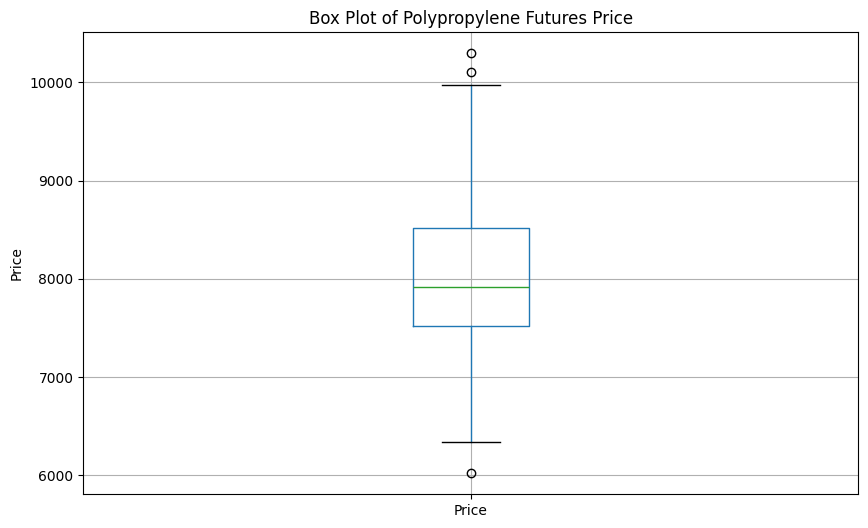

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.boxplot(column=['Price'])
plt.title('Box Plot of Polypropylene Futures Price')
plt.ylabel('Price')
plt.grid(True)
plt.show()

### Interpretation of Box Plot

The box plot of the Polypropylene Futures Price provides a visual summary of the data's distribution:

*   The **box** represents the interquartile range (IQR), spanning from the 25th percentile (Q1) to the 75th percentile (Q3).
*   The **line inside the box** indicates the median (50th percentile), which appears to be close to the mean, suggesting a relatively symmetrical distribution within the bulk of the data.
*   The **whiskers** extend to 1.5 times the IQR from Q1 and Q3, capturing the majority of the data. Prices outside these whiskers are considered potential outliers.
*   **Individual points** beyond the whiskers are indeed identified as outliers, indicating some extreme price fluctuations both on the higher and lower ends.

# 6. Identify Outliers (1.5*IQR Rule)

In [8]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

if not outliers.empty:
    print(f"Outliers detected (prices outside {lower_bound:.2f} and {upper_bound:.2f}):")
    display(outliers)
else:
    print("No outliers detected based on the 1.5*IQR rule.")

Outliers detected (prices outside 6030.50 and 10002.50):


,Price
Date,
2020-03-30,6021.0
2021-10-11,10296.0
2021-10-12,10107.0


### Interpretation of Outlier Identification

Using the 1.5 * IQR rule, the following outliers were detected:

*   **2020-03-30**: A price of `6021.0`. This value falls below the calculated `lower_bound` of 6030.50, indicating an unusually low price point.
*   **2021-10-11**: A price of `10296.0`. This value exceeds the calculated `upper_bound` of 10002.50, indicating an unusually high price point.
*   **2021-10-12**: A price of `10107.0`. This value also exceeds the calculated `upper_bound`, representing another significantly high price point.

These outliers highlight specific dates with extreme price movements that might warrant further investigation to understand their causes (e.g., market events, economic shifts).

# 7. Generate Line Plot to Visualize Trend

Having look at the trend

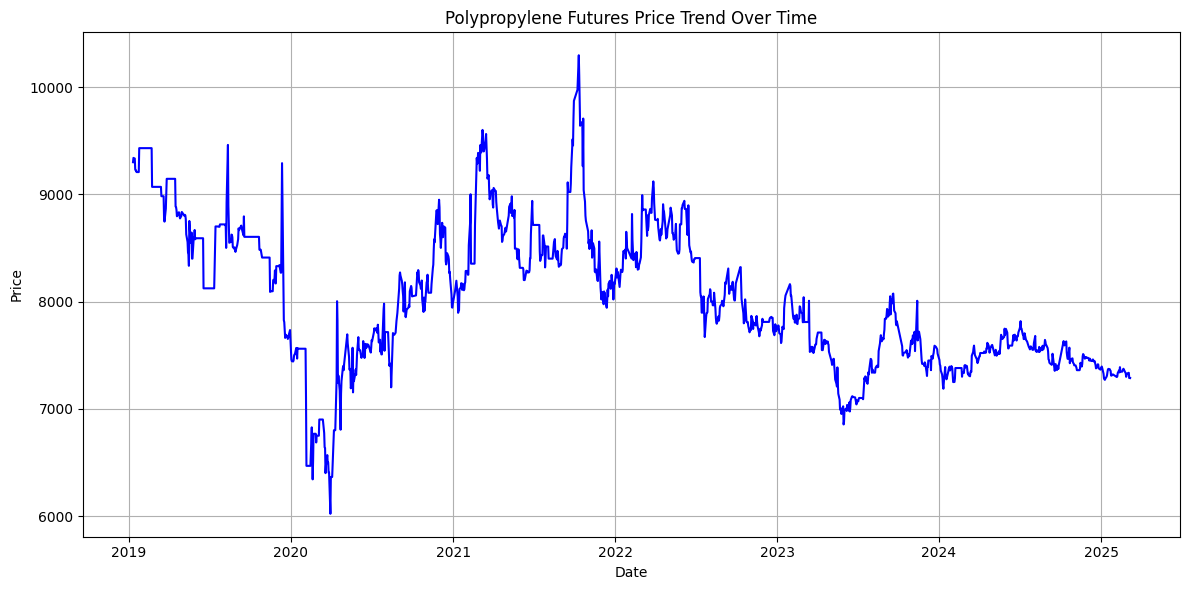

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price'], linestyle='-', color='b')
plt.title('Polypropylene Futures Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Original Price Trend

The line plot of the Polypropylene Futures Price over time (`2019` to `2025`) reveals the following trends:

*   **Early 2019 - Mid 2020**: Prices generally show a downward trend, with a significant dip around early 2020, possibly correlating with global economic events (e.g., the onset of the COVID-19 pandemic).
*   **Mid 2020 - Late 2021**: A strong upward trend is observed, with prices reaching their peak in late 2021. This period could reflect recovery and increased demand.
*   **Late 2021 - Early 2023**: A noticeable downtrend follows the peak, indicating a correction or stabilization in prices.
*   **Early 2023 - Early 2025**: Prices appear to stabilize and fluctuate within a narrower range, perhaps showing some signs of a slight recovery or sideways movement.

Overall, the plot clearly visualizes the dynamic nature of futures prices, with periods of significant volatility and clear directional trends.

# 8. Scale the Data using StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the 'Price' column and transform it
# Reshape -1, 1 is required for a single feature
df['Price_Scaled'] = scaler.fit_transform(df[['Price']])

print("DataFrame after adding scaled 'Price' column:")
display(df.head())

DataFrame after adding scaled 'Price' column:


,Price,Price_Scaled
Date,,
2019-01-10,9299.0,1.970922
2019-01-11,9339.0,2.032115
2019-01-14,9333.0,2.022936
2019-01-15,9232.0,1.868425
2019-01-16,9222.0,1.853127


### Interpretation of Scaled Data

After applying `StandardScaler` to the 'Price' column, a new column `Price_Scaled` has been added to the DataFrame. The `display(df.head())` output now shows:

*   The original `Price` values.
*   The corresponding `Price_Scaled` values, which are centered around `0` with a standard deviation of `1`.

For example, an original price of `9299.0` corresponds to a `Price_Scaled` value of `1.97`, indicating it is nearly two standard deviations above the mean. Conversely, prices below the mean will have negative scaled values. This transformation is crucial for many machine learning models, as it helps prevent features with larger numerical ranges from dominating the learning process.

## 9. Visualize Scaled Data

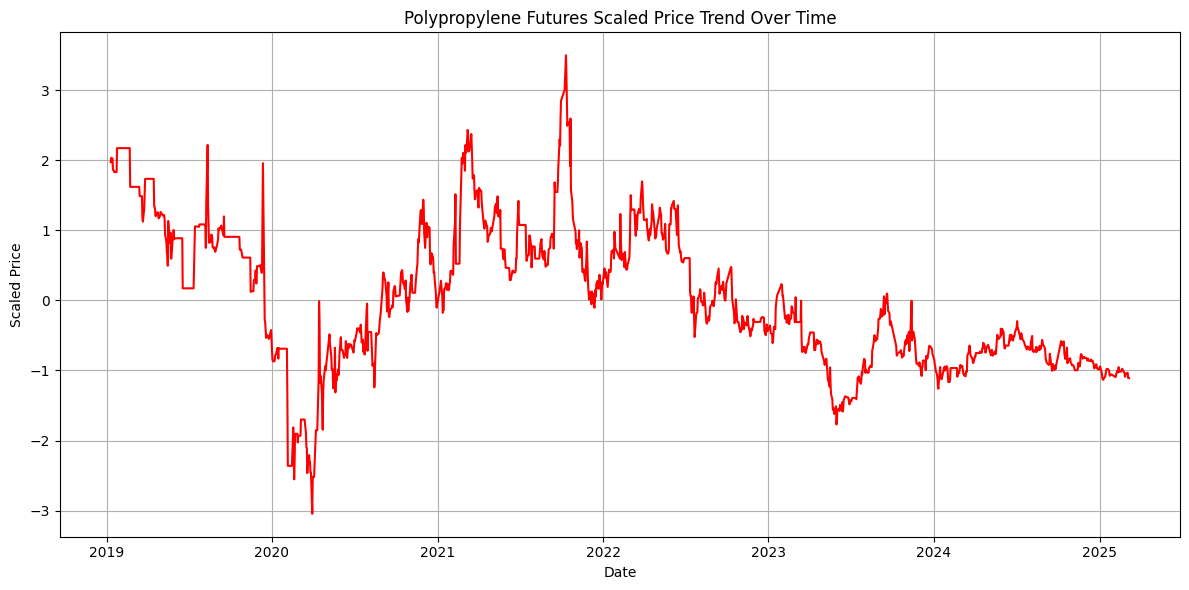

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price_Scaled'], linestyle='-', color='r')
plt.title('Polypropylene Futures Scaled Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Scaled Price Trend

The line plot for the `Price_Scaled` data demonstrates the trend of the futures prices after standardization. While the numerical values on the y-axis have changed (now centered around 0), the **shape and pattern of the trend remain identical** to the original price trend plot. This confirms that standardization only rescales the data, preserving the underlying temporal relationships and fluctuations. This scaled representation is particularly useful for models that rely on distances or gradients, as it ensures all features contribute proportionally.

### Improved Distribution Comparison: Histograms

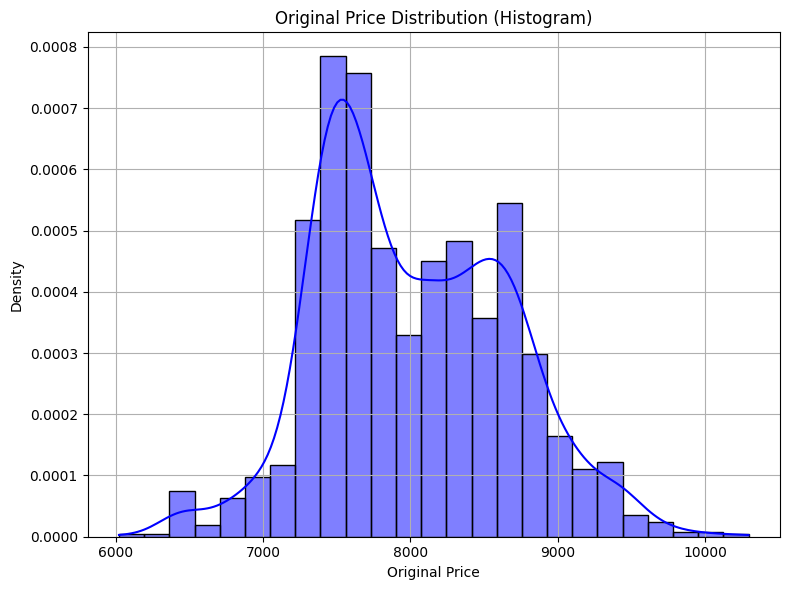

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], color='blue', kde=True, stat='density')
plt.title('Original Price Distribution (Histogram)')
plt.xlabel('Original Price')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Improved Histogram

This histogram provides a clear view of the original price distribution:

*   **Original Price Distribution**: The histogram for the original price clearly shows its actual range, with a central tendency around the mean (~8000) and specific bins highlighting the frequency of prices within those ranges. The KDE (Kernel Density Estimate) overlay provides a smoothed representation of the underlying probability distribution.

### Improved Distribution Comparison: Density Plots

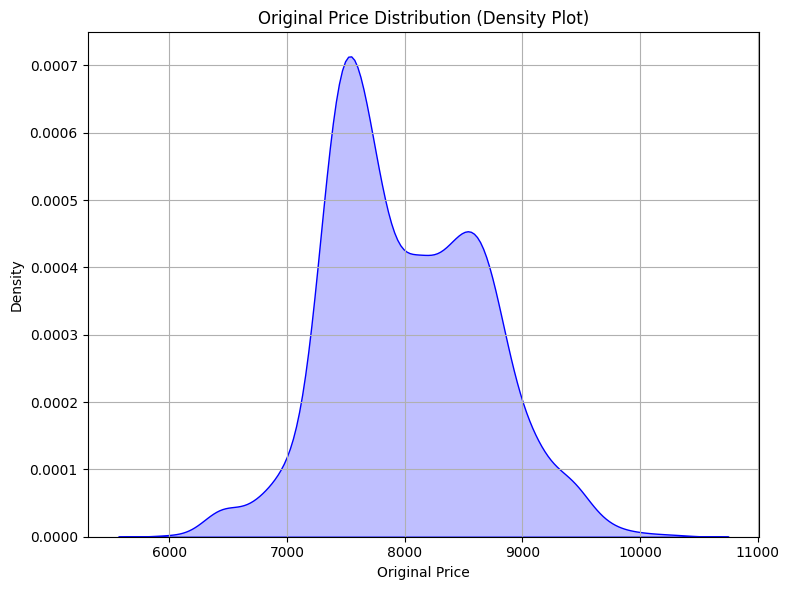

In [21]:
plt.figure(figsize=(8, 6))
sns.kdeplot(df['Price'], color='blue', fill=True)
plt.title('Original Price Distribution (Density Plot)')
plt.xlabel('Original Price')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Improved Density Plot

This density plot offers an enhanced view of the original price distribution:

*   **Original Price Distribution**: The density plot for the original price smoothly illustrates its probability density function (PDF) across its actual value range. It highlights the areas where price observations are most concentrated and visually confirms the overall shape of the distribution.

## 10. Time Series Decomposition

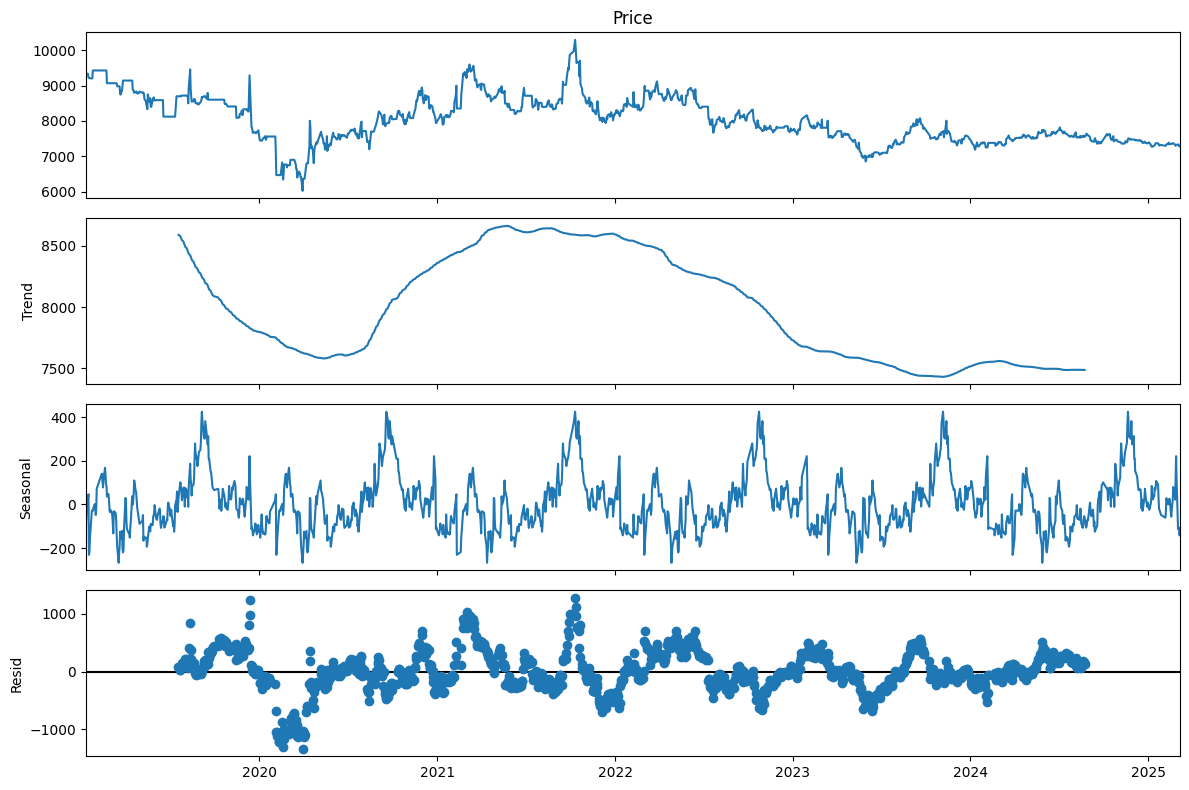

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition
decomposition = seasonal_decompose(df['Price'], model='additive', period=252) # Assuming daily data, ~252 trading days in a year

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### Interpretation of Time Series Decomposition

The additive time series decomposition of the Polypropylene Futures Price reveals the underlying components:

*   **Original (Top Panel)**: This is the raw time series data, showing the overall pattern and fluctuations we've observed previously.
*   **Trend (Second Panel)**: This component captures the long-term direction of the series. We can clearly see the upward trend from mid-2020 to late 2021 and the subsequent downward trend, consistent with our earlier line plot observations. The trend component is a smoothed version of the original series, removing short-term fluctuations.
*   **Seasonal (Third Panel)**: This component represents the recurring patterns or cycles in the data over a fixed period (in this case, an assumed annual cycle of 252 trading days). If there is a noticeable pattern, it would repeat itself at regular intervals. For this specific data, the seasonal component appears to be relatively small and less pronounced compared to the trend and residual, suggesting that strong, consistent yearly seasonality might not be a dominant factor or is too subtle to be captured easily with this model/period.
*   **Residual (Bottom Panel)**: This component represents the random, irregular fluctuations in the data after the trend and seasonal components have been removed. It is essentially the 'noise' left over. Analyzing the residuals can help assess if the model has captured the underlying patterns effectively. If the residuals show no clear pattern (i.e., they are random), it suggests a good fit. Any remaining patterns in the residuals might indicate uncaptured information in the data.

## 11. Time Series Smoothing: Moving Averages

Moving Averages are widely used technical indicators that smooth out price data by creating a constantly updated average price. They help to identify trends and reduce noise.

There are several types of moving averages; here we will demonstrate two common ones: Simple Moving Average (SMA) and Exponential Moving Average (EMA).

### Simple Moving Average (SMA)

An SMA is calculated by taking the arithmetic mean of prices over a specified period. It gives equal weight to all data points in the period. We will calculate a 30-day SMA for the 'Price' data.

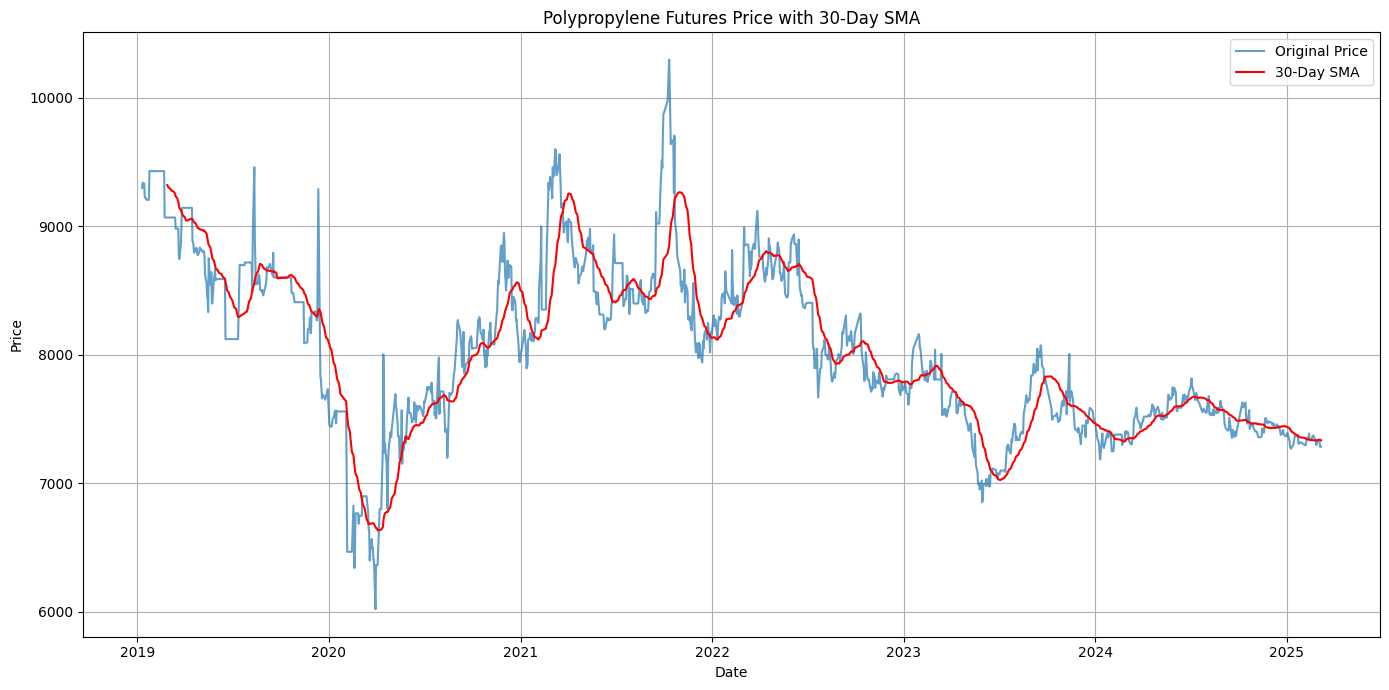

In [22]:
# Calculate 30-day Simple Moving Average (SMA)
df['SMA_30'] = df['Price'].rolling(window=30).mean()

# Plot original price and SMA
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Price'], label='Original Price', alpha=0.7)
plt.plot(df.index, df['SMA_30'], label='30-Day SMA', color='red')
plt.title('Polypropylene Futures Price with 30-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of 30-Day SMA

*   The 30-Day Simple Moving Average (SMA) line is much smoother than the original price data, indicating its effectiveness in reducing short-term fluctuations and noise.
*   It helps to visualize the underlying trend more clearly. When the price is above the SMA, it suggests an uptrend, and when it's below, it suggests a downtrend.
*   The SMA lags behind the price action because it gives equal weight to all data points within its window. This lag is a characteristic of SMAs, meaning it will react slower to new price changes compared to the original series.

### Exponential Moving Average (EMA)

An EMA gives more weight to recent prices, making it more responsive to new information compared to a Simple Moving Average. We will calculate a 30-day EMA for the 'Price' data.

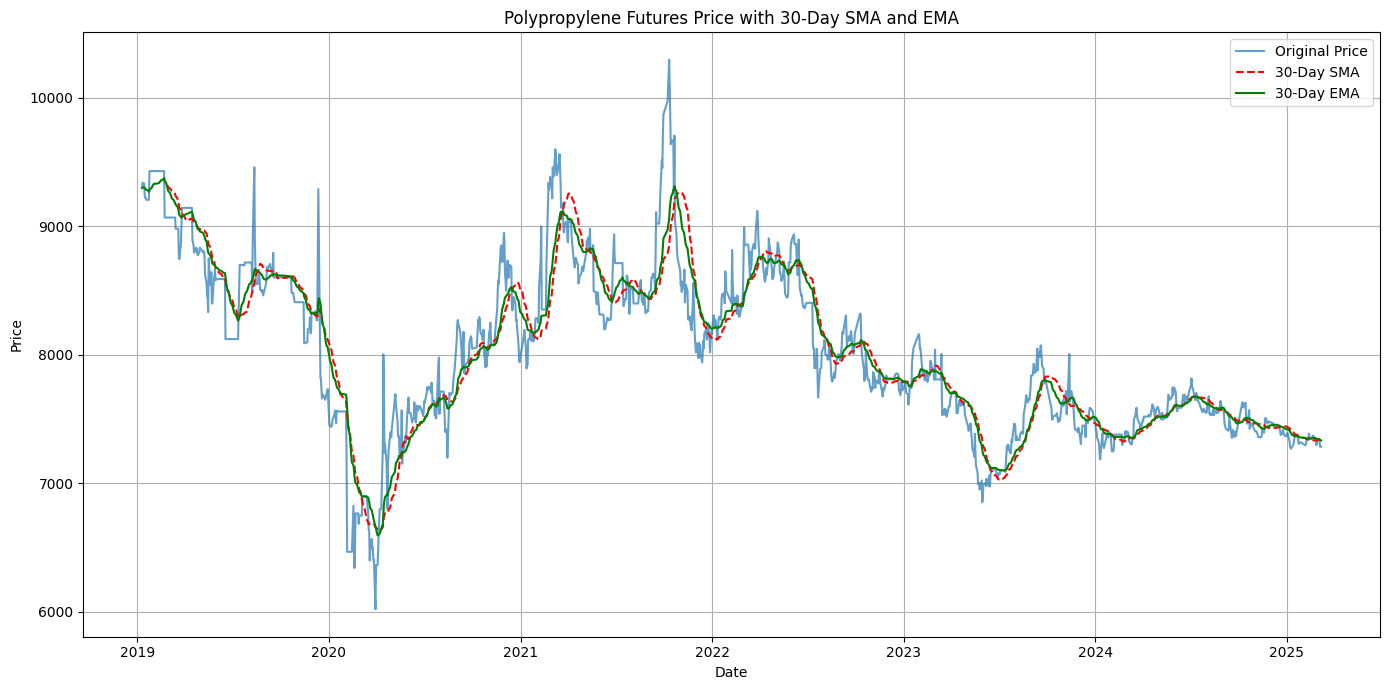

In [23]:
# Calculate 30-day Exponential Moving Average (EMA)
df['EMA_30'] = df['Price'].ewm(span=30, adjust=False).mean()

# Plot original price, SMA, and EMA for comparison
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Price'], label='Original Price', alpha=0.7)
plt.plot(df.index, df['SMA_30'], label='30-Day SMA', color='red', linestyle='--')
plt.plot(df.index, df['EMA_30'], label='30-Day EMA', color='green')
plt.title('Polypropylene Futures Price with 30-Day SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of 30-Day EMA

*   The 30-Day Exponential Moving Average (EMA) is also a smoothed line, but it generally follows the price more closely than the SMA. This is because the EMA gives higher weighting to the most recent data points.
*   When compared to the SMA, the EMA often appears to be 'closer' to the original price line, especially during periods of strong trends, as it reacts more quickly to price changes.
*   Both moving averages help in identifying the trend direction. The choice between SMA and EMA often depends on whether you prefer a smoother, less responsive indicator (SMA) or a more responsive one that reflects recent changes more heavily (EMA).

## 12. Stationarity Check

Stationarity is a key assumption in many time series models. A stationary time series is one whose statistical properties (mean, variance, autocorrelation) do not change over time. We will use the Augmented Dickey-Fuller (ADF) test to check for stationarity.

In [24]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
result = adfuller(df['Price'])

# Extract and print the results
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result[1] <= 0.05:
    print("\nConclusion: The p-value is less than or equal to 0.05. We reject the null hypothesis, meaning the time series is likely stationary.")
else:
    print("\nConclusion: The p-value is greater than 0.05. We fail to reject the null hypothesis, meaning the time series is likely non-stationary.")

ADF Statistic: -3.039573
p-value: 0.031360
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568

Conclusion: The p-value is less than or equal to 0.05. We reject the null hypothesis, meaning the time series is likely stationary.


### Interpretation of Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is a statistical test for stationarity. The null hypothesis of the ADF test is that the time series is non-stationary (i.e., it has a unit root).

*   **ADF Statistic**: A more negative value suggests a stronger rejection of the null hypothesis (i.e., more stationary).
*   **p-value**: This is the probability of observing results as extreme as, or more extreme than, the results observed under the null hypothesis. A low p-value (typically ≤ 0.05) indicates strong evidence against the null hypothesis, suggesting that the time series is stationary.
*   **Critical Values**: These are the values at which you would reject the null hypothesis at different significance levels (e.g., 1%, 5%, 10%). If the ADF Statistic is less than the critical value at a certain significance level, you reject the null hypothesis at that level.

**Conclusion**: Based on the comparison of the p-value with a common significance level (e.g., 0.05), we can determine whether the time series is stationary or not. If the p-value is greater than 0.05, it suggests the presence of a unit root, indicating that the series is non-stationary and may require differencing to achieve stationarity for certain modeling techniques.

## 13. Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) Plots

ACF and PACF plots are crucial tools in time series analysis for identifying the order of an Autoregressive Integrated Moving Average (ARIMA) model.

*   **ACF Plot (Autocorrelation Function)**: Shows the correlation of a time series with its own past values at different lags. It helps in identifying the moving average (MA) order, denoted as `q`.
*   **PACF Plot (Partial Autocorrelation Function)**: Shows the direct correlation of a time series with its own past values, after removing the linear dependence of the intermediate lags. It helps in identifying the autoregressive (AR) order, denoted as `p`.

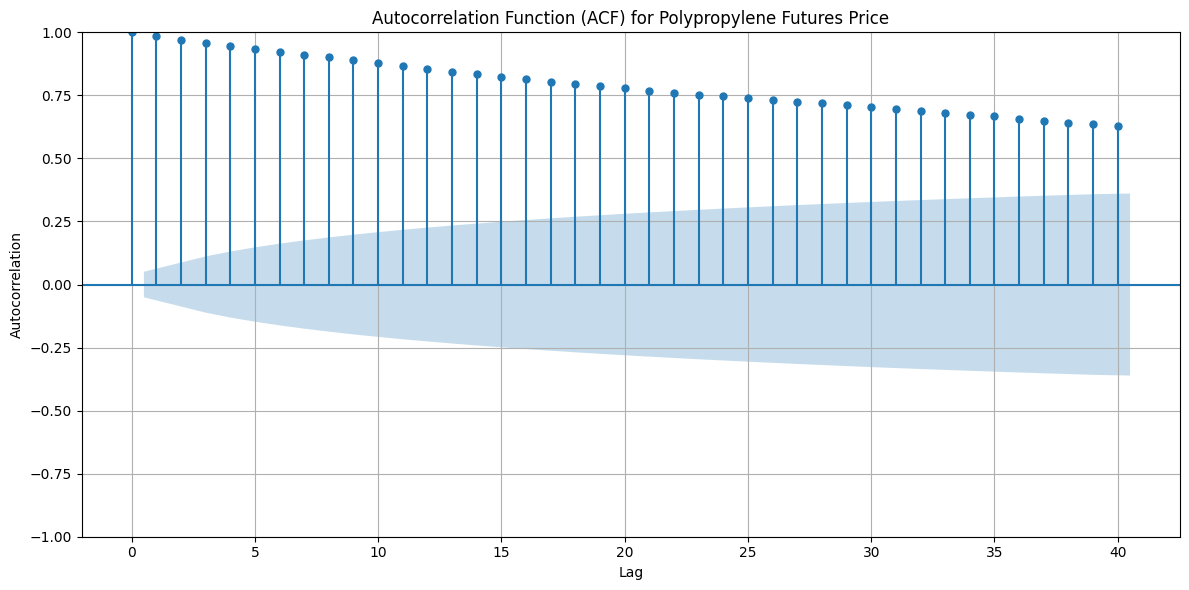

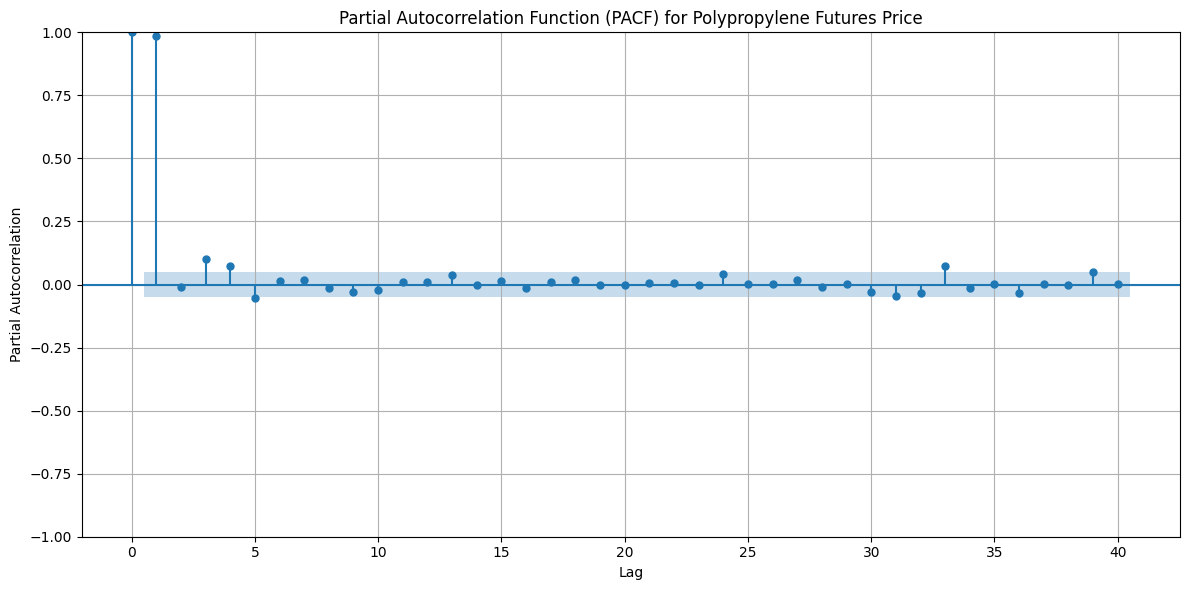

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
fig_acf = plot_acf(df['Price'], lags=40, alpha=0.05)
fig_acf.set_size_inches(12, 6)
plt.title('Autocorrelation Function (ACF) for Polypropylene Futures Price')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot PACF
fig_pacf = plot_pacf(df['Price'], lags=40, alpha=0.05)
fig_pacf.set_size_inches(12, 6)
plt.title('Partial Autocorrelation Function (PACF) for Polypropylene Futures Price')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of ACF and PACF Plots

*   **ACF Plot**: We observe how the autocorrelation tails off or cuts off. The number of lags where the ACF crosses the significance boundaries (blue shaded area) and then drops sharply or stays within is indicative of the `q` parameter (Moving Average order).
*   **PACF Plot**: We observe how the partial autocorrelation tails off or cuts off. The number of significant lags in the PACF plot (where the bars extend beyond the blue shaded area) before it drops sharply or remains within significance is indicative of the `p` parameter (Autoregressive order).

Based on these plots, we can make an informed decision about the appropriate `p` and `q` values for an ARIMA model. A tailing off pattern in ACF and a sharp cut-off in PACF usually suggests an AR model, while a tailing off in PACF and a sharp cut-off in ACF suggests an MA model. If both tail off, an ARMA model might be appropriate.

## 14. ARIMA Model Training

Based on the previous analysis, particularly the PACF plot suggesting a sharp cut-off after lag 1, we will now train an ARIMA(1,0,0) model. This model consists of:

*   **AR (Autoregressive) order (p) = 1**: Indicates that the current value of the series is dependent on its immediately preceding value.
*   **I (Integrated) order (d) = 0**: Means no differencing is applied, as the Augmented Dickey-Fuller test suggested the series is stationary.
*   **MA (Moving Average) order (q) = 0**: Indicates that the model does not use the residual error from previous forecasts.

In [26]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA model parameters (p, d, q)
arima_order = (1, 0, 0)

# Create and fit the ARIMA model
# The 'Price' column is already the DataFrame's index
model = ARIMA(df['Price'], order=arima_order)
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1491
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -9108.215
Date:                Mon, 10 Aug 2026   AIC                          18222.430
Time:                        17:58:27   BIC                          18238.352
Sample:                             0   HQIC                         18228.363
                               - 1491                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       8010.6602    201.530     39.749      0.000    7615.669    8405.651
ar.L1          0.9870      0.003    285.704      0.000       0.980       0.994
sigma2      1.182e+04    154.765     76.348      0.0

## 15. Residual Diagnostic Plots

After fitting an ARIMA model, it's essential to examine its residuals to ensure that the model has captured all the underlying patterns in the data and that the residuals resemble white noise (i.e., they are uncorrelated, have a constant variance, and are normally distributed with a zero mean).

We will use `model_fit.plot_diagnostics()` to generate four standard diagnostic plots:

1.  **Standardized Residuals**: A plot of the standardized residuals over time. Ideally, these should fluctuate randomly around zero with no discernible pattern.
2.  **Histogram plus kde estimate**: A histogram of the residuals along with a Kernel Density Estimate (KDE) plot. This helps to check if the residuals are normally distributed.
3.  **Normal Q-Q**: A Quantile-Quantile plot to compare the distribution of the residuals against a standard normal distribution. If the residuals are normally distributed, the points should lie approximately along the 45-degree line.
4.  **Correlogram (ACF Plot of Residuals)**: An Autocorrelation Function (ACF) plot of the residuals. For a good model, the residuals should not have any significant autocorrelation, meaning all bars (except possibly at lag 0) should fall within the confidence intervals.

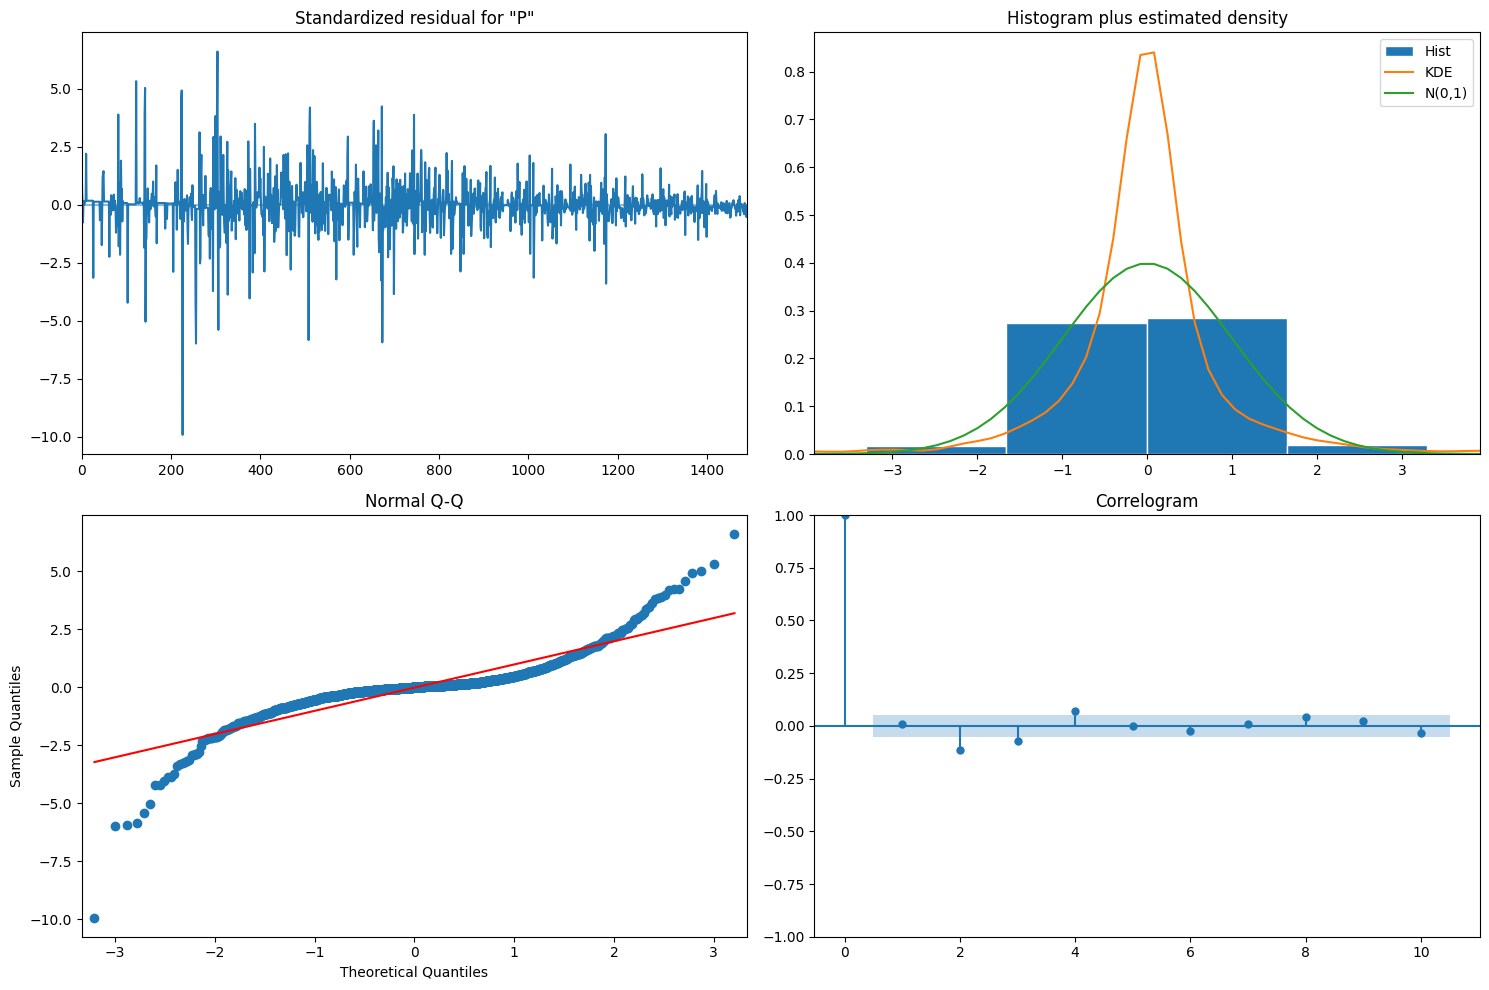

In [27]:
import matplotlib.pyplot as plt

# Plot the residuals diagnostics
fig = model_fit.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

### Interpretation of Residual Diagnostic Plots

Let's analyze each of the four plots generated by `model_fit.plot_diagnostics()`:

1.  **Standardized Residuals (Top-Left Plot)**:
    *   We observe the residuals over time. For a good model, these should look like random noise, fluctuating around zero without any clear patterns, trends, or changes in variance. Any visible pattern or increasing/decreasing variance would indicate that the model has not fully captured the dynamics of the time series.

2.  **Histogram plus kde estimate (Top-Right Plot)**:
    *   This plot shows the distribution of the residuals. Ideally, the residuals should be normally distributed, centered around zero. The histogram should roughly follow the normal distribution curve (KDE line).
    *   If the shape deviates significantly from a normal distribution, it suggests that the model's assumptions about the error terms might be violated.

3.  **Normal Q-Q (Bottom-Left Plot)**:
    *   This plot compares the quantiles of the residuals to the quantiles of a theoretical normal distribution. If the residuals are normally distributed, the points should lie closely along the 45-degree red line.
    *   Deviations from this line, especially at the tails, indicate non-normality, which is consistent with the Jarque-Bera test results from the model summary.

4.  **Correlogram (ACF Plot of Residuals) (Bottom-Right Plot)**:
    *   This is an ACF plot applied to the residuals. For a well-fitted model, the residuals should exhibit no significant autocorrelation at any lag (i.e., all the bars should fall within the blue shaded confidence intervals).
    *   If any bars extend beyond these intervals, it suggests that there is still some patterned information left in the residuals that the model failed to capture, indicating potential for further model improvement.

**Overall Assessment:**

Based on these plots, we can assess the ARIMA(1,0,0) model's adequacy. For instance, if the correlogram shows no significant autocorrelation, it suggests that the AR(1) term was sufficient to model the linear dependencies. However, if the Q-Q plot shows deviations from normality or the histogram is not bell-shaped, it implies that the error terms are not Gaussian, potentially affecting confidence intervals and p-values.

## 16. Forecasting with ARIMA Model

After fitting the ARIMA model and performing diagnostic checks on the residuals, the next step is to use the model for forecasting. To evaluate the model's forecasting ability, we will split our data into a training set and a testing set. The model will be trained on the historical data (training set), and then its performance will be assessed on the unseen data (testing set).

We will perform a simple train-test split, reserving the last portion of the data for testing.

In [30]:
# Define the split point for training and testing
# Let's use the last 60 observations (approximately 3 months of daily data) as the test set
train_size = len(df) - 60
train_data, test_data = df['Price'][0:train_size], df['Price'][train_size:]

print(f"Training data points: {len(train_data)}")
print(f"Testing data points: {len(test_data)}")

# Re-fit the ARIMA model on the training data
# We use the same ARIMA order (1,0,0) as determined earlier
model_train = ARIMA(train_data, order=arima_order)
model_train_fit = model_train.fit()

# Generate predictions for the test set
start_index = len(train_data)
end_index = len(df) - 1
predictions = model_train_fit.predict(start=start_index, end=end_index, dynamic=False)

# Assign the correct datetime index to predictions
predictions.index = test_data.index

# Create a DataFrame for predictions to easily plot and compare
predictions_df = pd.DataFrame(predictions, index=test_data.index, columns=['Predicted_Price'])

print("\nFirst 5 actual vs. predicted values:")
display(pd.DataFrame({'Actual': test_data, 'Predicted': predictions}).head())

Training data points: 1431
Testing data points: 60


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



First 5 actual vs. predicted values:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,Actual,Predicted
Date,,
2024-12-05,7449.0,7469.896762
2024-12-06,7468.0,7477.685257
2024-12-09,7446.0,7485.366968
2024-12-10,7446.0,7492.943360
2024-12-11,7446.0,7500.415877


### Visualize Forecasts vs. Actuals

To visually assess the model's performance, we will plot the original 'Price' data, the training data, and the forecasted values against the actual test data.

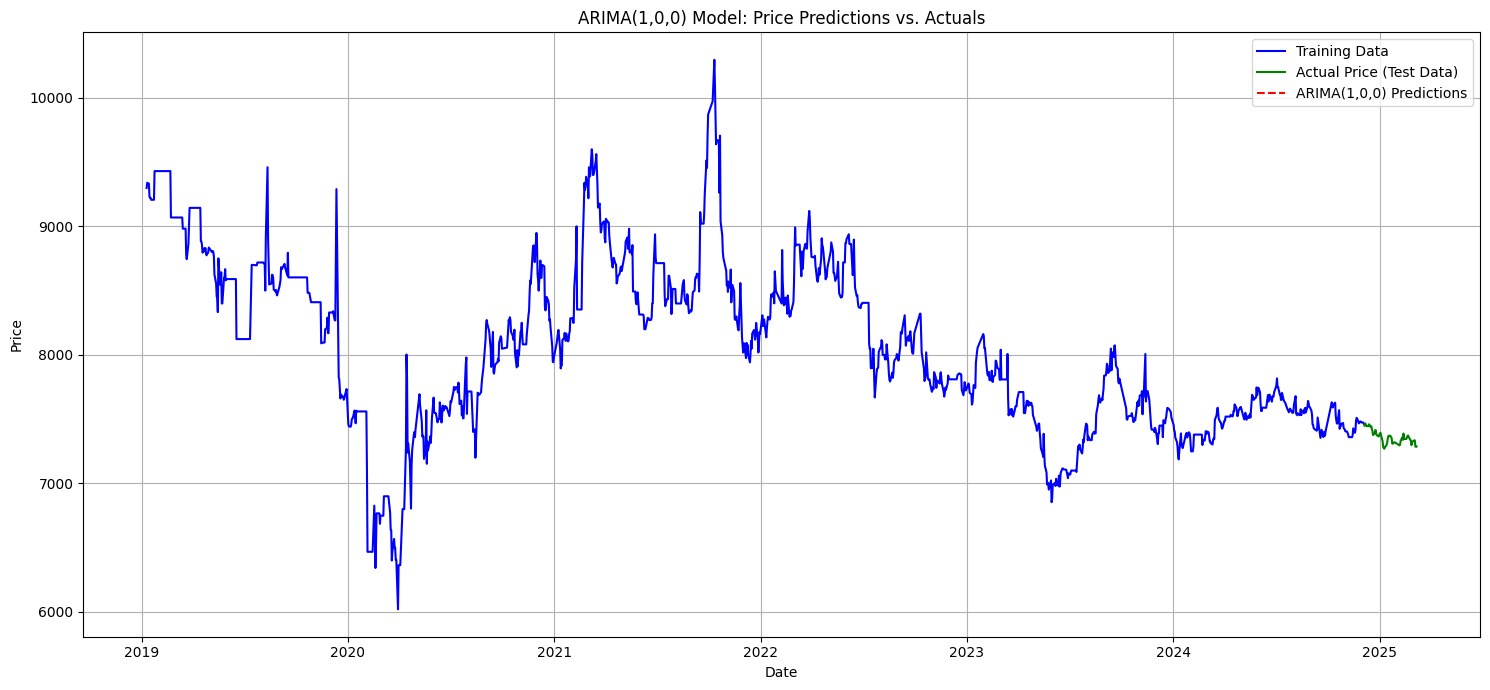

In [29]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Price (Test Data)', color='green')
plt.plot(predictions_df.index, predictions_df['Predicted_Price'], label='ARIMA(1,0,0) Predictions', color='red', linestyle='--')
plt.title('ARIMA(1,0,0) Model: Price Predictions vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Forecasts

*   **Visual Comparison**: The plot allows for a direct visual comparison between the actual prices in the test set and the prices predicted by our ARIMA(1,0,0) model. We can observe how well the red dashed prediction line follows the green actual price line.
*   **Bias and Variance**: We can visually identify if the model consistently over- or under-predicts (bias) and how much the predictions deviate from the actual values (variance).
*   **Lag**: Due to the autoregressive nature and the inherent lag in time series forecasting, the predictions might lag behind sharp changes in the actual series.

To quantitatively evaluate the forecasting performance, we would typically calculate metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), or Mean Absolute Percentage Error (MAPE) between the `test_data` and the `predictions`.

## 17. Evaluate Forecasting Performance: RMSE and MAE

To quantitatively assess the performance of our ARIMA model, we will calculate two common metrics:

*   **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors in a set of forecasts, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.
*   **Root Mean Squared Error (RMSE)**: A quadratic scoring rule that measures the average magnitude of the error. It's the square root of the average of squared differences between prediction and actual observation. Since the errors are squared before they are averaged, the RMSE gives a relatively high weight to large errors. This means the RMSE is most useful when large errors are particularly undesirable.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure test_data and predictions are aligned (already done in previous cell)

# Calculate MAE
mae = mean_absolute_error(test_data, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_data, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 289.70
Root Mean Squared Error (RMSE): 319.90
